# Supplementary Figure S5(B) — Average pair score by deposition year

Yearly mean pair score by method.

In [1]:
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
COLORS = {"X-ray": "#4A90D9", "EM": "#E55050"}


LABELS = {"X-ray": "X-ray", "EM": "Cryo-EM"}


def _resolution(m):
    return (m.get("EM Diffraction Resolution (Å)") or m.get("Refinement_resolution")
            or m.get("EM Resolution (Å)"))


def _year(s):
    if not s:
        return None
    try:
        return datetime.fromisoformat(s).year
    except Exception:
        return None


def load_temporal_df():
    """Per-structure rows (>=5 pairs) with year, method, resolution, pairs_score."""
    sc = json.load(open(data_file("reference/scores/scores_all_uniques.json")))["scores"]
    vm = json.load(open(data_file("reference/metadata/metadata_cache.json")))["validation_metrics"]
    rows = []
    for pdb, info in sc.items():
        m = vm.get(pdb)
        if not isinstance(m, dict):
            continue
        year = _year(m.get("Deposition_Date"))
        method = m.get("Experimental_method")
        res = _resolution(m)
        if year is None or method not in ("X-ray", "EM") or res is None or res <= 0:
            continue
        rows.append({"pdb": pdb, "year": year, "method": method, "resolution": res,
                     "pairs_score": info["pairs_score"], "n_pairs": info.get("n_pairs", 0)})
    df = pd.DataFrame(rows)
    return df[df["n_pairs"] >= 5].reset_index(drop=True)


def yearly_agg(df):
    agg = (df.groupby(["method", "year"])
             .agg(resolution_mean=("resolution", "mean"), resolution_sem=("resolution", "sem"),
                  pairs_mean=("pairs_score", "mean"), pairs_sem=("pairs_score", "sem"),
                  n=("pdb", "count"))
             .reset_index().sort_values(["method", "year"]))
    for c in ("resolution_sem", "pairs_sem"):
        agg[c] = agg[c].fillna(0)
    return agg


def plot_trend(ax, agg, mean_col, sem_col, ylabel, title, invert_y=False):
    """Yearly-mean trend with per-method points, SEM bars, and linear fits."""
    em_first = int(agg[agg.method == "EM"].year.min())
    box_y = 0.02
    for method in ("X-ray", "EM"):
        sub = agg[agg.method == method].sort_values("year")
        if sub.empty:
            continue
        c = COLORS[method]
        ax.errorbar(sub.year, sub[mean_col], yerr=sub[sem_col], fmt="o-", color=c, ecolor=c,
                    capsize=2.5, alpha=0.9, markersize=6, linewidth=2.2, elinewidth=0.9,
                    label=LABELS[method])
        if len(sub) >= 3:
            res = linregress(sub.year, sub[mean_col])
            xx = np.linspace(sub.year.min(), sub.year.max(), 50)
            ax.plot(xx, res.slope * xx + res.intercept, "--", color=c, linewidth=1.2, alpha=0.8)
            ax.text(0.02, box_y, f"{LABELS[method]}: {res.slope:+.2f}/yr", transform=ax.transAxes,
                    ha="left", va="bottom", fontsize=9, color=c, fontweight="bold",
                    family="monospace",
                    bbox=dict(boxstyle="round", facecolor="white", edgecolor=c, alpha=0.9, linewidth=1.5))
            box_y += 0.08
    ax.axvline(em_first, color="#E55050", linestyle="--", linewidth=1.0, alpha=0.7)
    ax.set_xlabel("Deposition Year", fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)
    if invert_y:
        ax.invert_yaxis()

In [3]:
df = load_temporal_df()
agg = yearly_agg(df)
em = df[df['method'] == 'EM'].dropna(subset=['year', 'resolution', 'pairs_score']).copy()

saved figures/figS5_B_pair_score_by_year.png


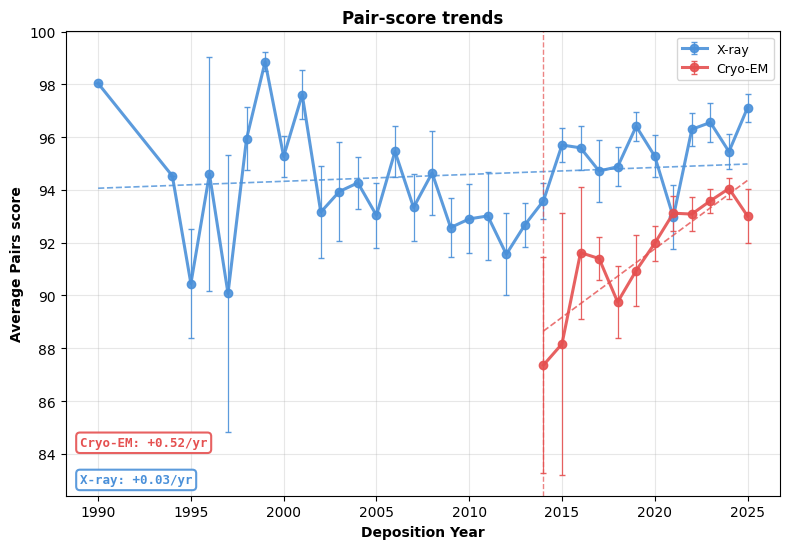

In [4]:
fig, ax = plt.subplots(figsize=(8, 5.6))
plot_trend(ax, agg, 'pairs_mean', 'pairs_sem',
              'Average Pairs score', 'Pair-score trends', invert_y=False)
fig.tight_layout(); print('saved', savefig(fig, 'figS5_B_pair_score_by_year.png')); plt.show()